# 05 - SHAP Analysis
**Cash Flow and AR Collection Intelligence System**

Goal: Validate that model explanations align with financial intuition and are tied to the current model artifacts.

Sections:
1. Portfolio-level feature importance
2. Feature interaction analysis
3. Customer segment deep-dive
4. Single invoice waterfall walkthrough
5. Narrative quality check
6. Audit validation


In [14]:
import hashlib
import json
import warnings
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import shap

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

start = Path.cwd().resolve()
candidates = [start, *start.parents]
project_root = next((p for p in candidates if (p / "src").exists() and (p / "config").exists()), start)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.classifier import get_Xy, load_model, predict as classify
from src.models.explainer import (
    SHAP_EXPLAINER_PATH,
    build_shap_explainer,
    compute_shap_values,
    generate_narrative,
    load_shap_explainer,
    plot_shap_bar,
    plot_shap_summary,
    plot_waterfall,
)
from src.utils.config import CLASSIFIER_CFG, CLASSIFIER_PATH, FEATURE_STORE_PATH

shap.initjs()

fs = pd.read_csv(FEATURE_STORE_PATH, parse_dates=["BLDAT"])
model, meta = load_model()
threshold = float(meta["threshold"])
X_all, y_all = get_Xy(fs)

print(f"Dataset: {len(fs):,} rows | Threshold: {threshold:.2f}")

15:38:56 | INFO     | src.models.classifier - Calibrator loaded from cashflow-intelligence/models_saved/classifier_calibrator.pkl
15:38:56 | INFO     | src.models.classifier - Model loaded from cashflow-intelligence/models_saved/classifier_xgb.json
Dataset: 4,995 rows | Threshold: 0.56


## 1. Portfolio-Level Feature Importance

In [15]:
# Reproducibility policy:
# - Default: always rebuild explainer from current model/features.
# - Optional fast path: cache allowed only when validated against model signature.
USE_VALIDATED_CACHE = False
EXPLAINER_META_PATH = SHAP_EXPLAINER_PATH.with_suffix(".meta.json")


def _classifier_file_fingerprint(path: Path) -> str:
    if not path.exists():
        return "missing"
    digest = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _current_signature() -> dict:
    return {
        "classifier_file": CLASSIFIER_PATH.name,
        "classifier_sha256": _classifier_file_fingerprint(CLASSIFIER_PATH),
        "feature_cols": list(CLASSIFIER_CFG.feature_cols),
        "n_features": len(CLASSIFIER_CFG.feature_cols),
        "threshold": threshold,
    }


current_sig = _current_signature()
loaded_from_cache = False

if USE_VALIDATED_CACHE and SHAP_EXPLAINER_PATH.exists() and EXPLAINER_META_PATH.exists():
    try:
        cached_sig = json.loads(EXPLAINER_META_PATH.read_text(encoding="utf-8"))
        if cached_sig == current_sig:
            explainer = load_shap_explainer()
            loaded_from_cache = True
        else:
            explainer = build_shap_explainer(model, X_all)
    except Exception:
        explainer = build_shap_explainer(model, X_all)
else:
    explainer = build_shap_explainer(model, X_all)

EXPLAINER_META_PATH.write_text(json.dumps(current_sig, indent=2), encoding="utf-8")
shap_vals = compute_shap_values(explainer, X_all)

source = "validated cache" if loaded_from_cache else "fresh rebuild"
print(f"Explainer source: {source}")
print(f"SHAP values shape: {shap_vals.shape}")
print(f"Expected value: {explainer.expected_value}")
print(f"Signature file: {EXPLAINER_META_PATH.name}")

15:38:57 | INFO     | src.models.explainer - Building SHAP TreeExplainer...
15:38:57 | SUCCESS  | src.models.explainer - SHAP explainer saved → cashflow-intelligence/models_saved/shap_explainer.pkl
15:38:57 | INFO     | src.models.explainer - Computing SHAP values for 4,995 rows...
15:39:03 | INFO     | src.models.explainer - SHAP values computed
Explainer source: fresh rebuild
SHAP values shape: (4995, 12)
Expected value: 0.2824777744850786
Signature file: shap_explainer.meta.json


15:39:04 | INFO     | src.models.explainer - Generating SHAP summary plot...
15:39:05 | SUCCESS  | src.models.explainer - SHAP summary plot saved → cashflow-intelligence/data/exports/shap_summary.png


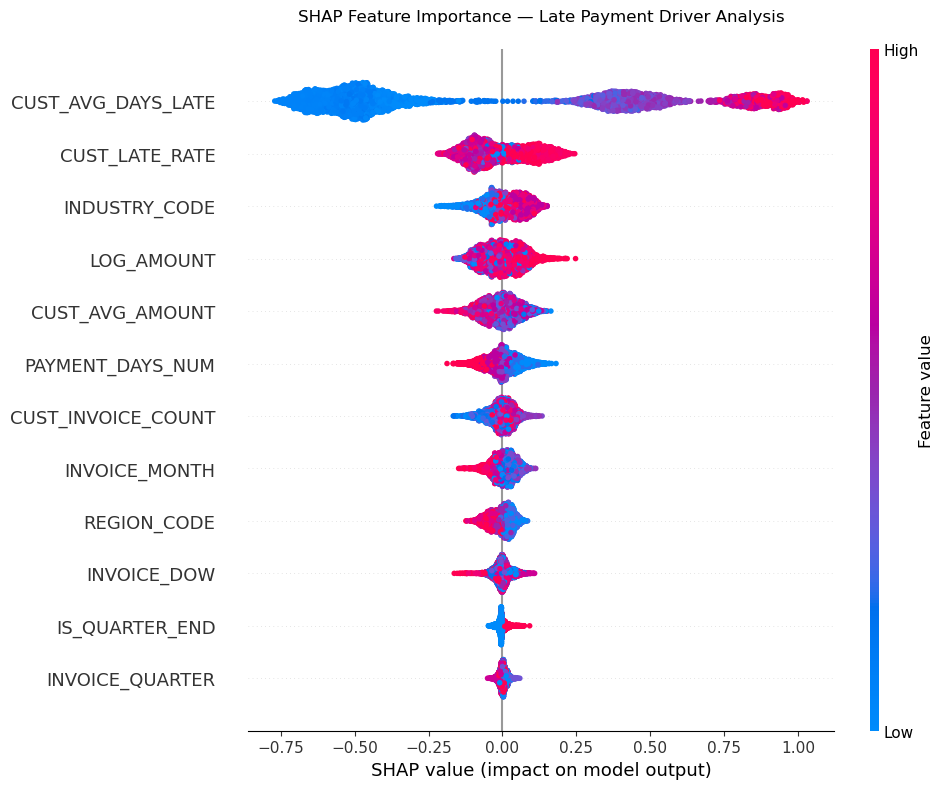

In [16]:
# Beeswarm summary: each dot is one invoice.
plot_shap_summary(shap_vals, X_all)

15:39:06 | SUCCESS  | src.models.explainer - SHAP bar chart saved → cashflow-intelligence/data/exports/shap_bar.png


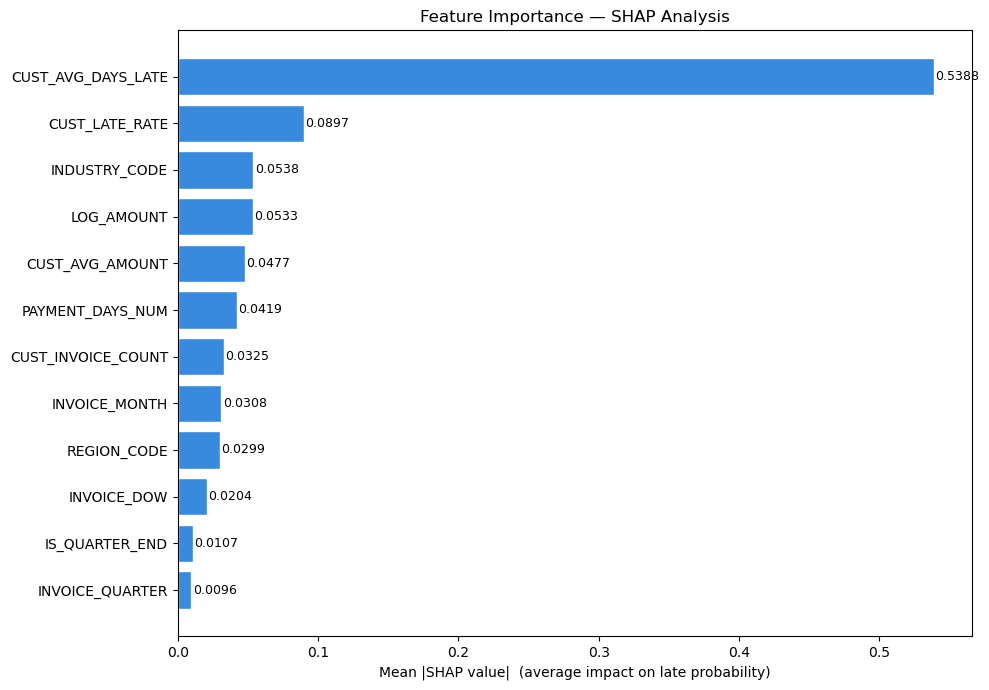


Feature ranking by SHAP impact:
           Feature  Mean |SHAP|
CUST_AVG_DAYS_LATE     0.538834
    CUST_LATE_RATE     0.089665
     INDUSTRY_CODE     0.053794
        LOG_AMOUNT     0.053332
   CUST_AVG_AMOUNT     0.047750
  PAYMENT_DAYS_NUM     0.041880
CUST_INVOICE_COUNT     0.032472
     INVOICE_MONTH     0.030844
       REGION_CODE     0.029885
       INVOICE_DOW     0.020435
    IS_QUARTER_END     0.010731
   INVOICE_QUARTER     0.009628


In [17]:
# Mean absolute SHAP ranking for portfolio-level drivers.
plot_shap_bar(shap_vals, X_all)

mean_abs = pd.DataFrame(
    {
        "Feature": CLASSIFIER_CFG.feature_cols,
        "Mean |SHAP|": np.abs(shap_vals).mean(axis=0),
    }
).sort_values("Mean |SHAP|", ascending=False)

print("\nFeature ranking by SHAP impact:")
print(mean_abs.to_string(index=False))

## 2. Feature Interaction Analysis

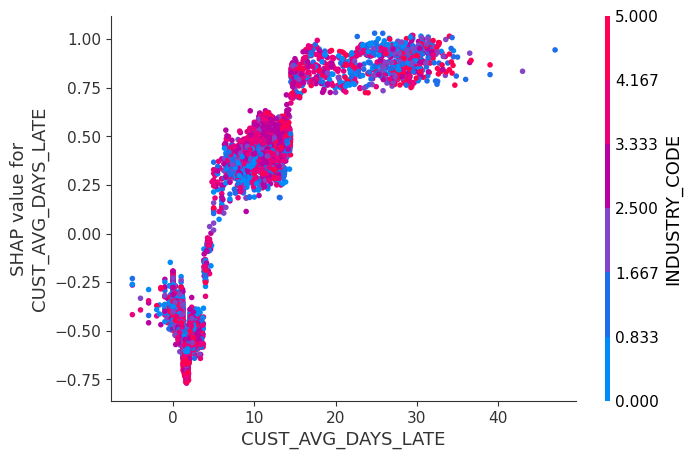

Text(0.5, 1.0, 'SHAP dependence: CUST_AVG_DAYS_LATE')

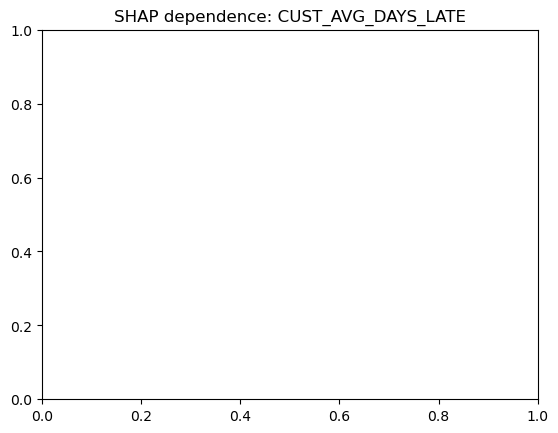

In [18]:
top_feature = mean_abs.iloc[0]["Feature"]

shap.dependence_plot(
    top_feature,
    shap_vals,
    X_all,
    feature_names=CLASSIFIER_CFG.feature_cols,
    interaction_index="auto",
    show=True,
)
plt.title(f"SHAP dependence: {top_feature}")

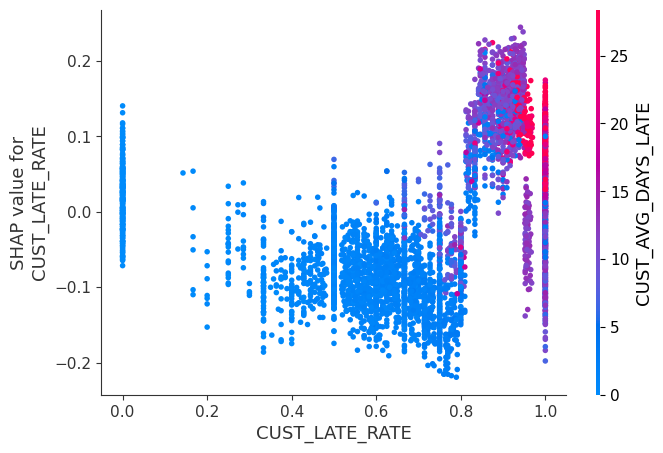

In [19]:
shap.dependence_plot(
    "CUST_LATE_RATE",
    shap_vals,
    X_all,
    feature_names=CLASSIFIER_CFG.feature_cols,
    interaction_index="CUST_AVG_DAYS_LATE",
    show=True,
)

## 3. Customer Segment Deep-Dive

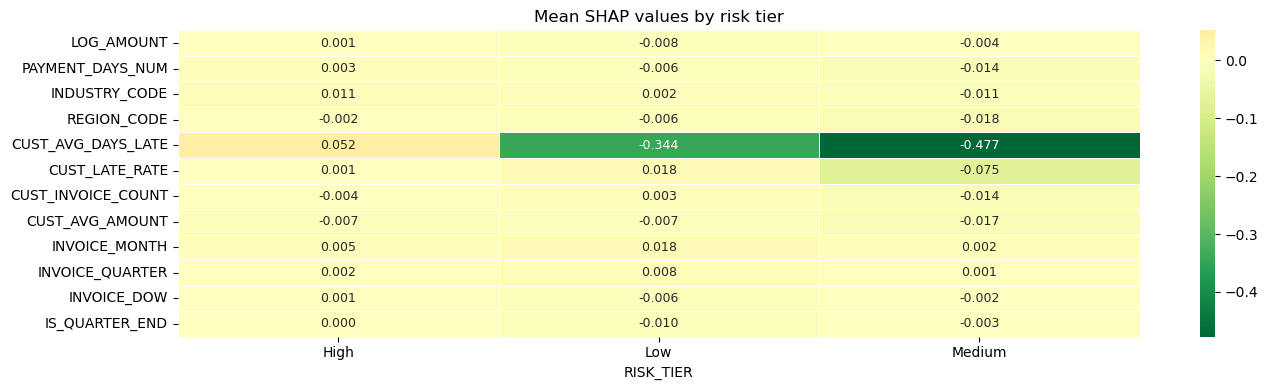

In [20]:
import seaborn as sns

scored = classify(model, fs, threshold)
shap_df = pd.DataFrame(shap_vals, columns=CLASSIFIER_CFG.feature_cols)
shap_df["RISK_TIER"] = fs["RISK_TIER"].values
shap_df["LATE_PROB"] = scored["LATE_PROB"].values

shap_by_tier = shap_df.groupby("RISK_TIER")[CLASSIFIER_CFG.feature_cols].mean()

plt.figure(figsize=(14, 4))
sns.heatmap(
    shap_by_tier.T,
    cmap="RdYlGn_r",
    center=0,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    annot_kws={"size": 9},
)
plt.title("Mean SHAP values by risk tier")
plt.tight_layout()
plt.show()

In [21]:
industry_risk = (
    scored.groupby("INDUSTRY")["LATE_PROB"]
    .agg(["mean", "std", "count"])
    .round(3)
    .sort_values("mean", ascending=False)
    .reset_index()
)

fig = px.bar(
    industry_risk,
    x="INDUSTRY",
    y="mean",
    error_y="std",
    title="Average Late Probability by Industry",
    labels={"mean": "Avg late probability", "INDUSTRY": "Industry"},
    color="mean",
    color_continuous_scale=["#1D9E75", "#EF9F27", "#E24B4A"],
)
fig.add_hline(y=threshold, line_dash="dash", annotation_text=f"Risk threshold ({threshold:.2f})")
fig.show()
print(industry_risk.to_string(index=False))

     INDUSTRY  mean   std  count
    Logistics 0.802 0.150    912
Manufacturing 0.775 0.170   1107
       Energy 0.756 0.170    577
       Retail 0.713 0.194    766
   Healthcare 0.710 0.172    717
 Construction 0.704 0.158    916


## 4. Single Invoice Waterfall Walkthrough

Invoice: 1800000624
Late probability: 96.9%
Risk tier: High
Industry: Healthcare | Region: Northeast
15:39:08 | INFO     | src.models.explainer - Generating waterfall for invoice 1800000624...
15:39:09 | SUCCESS  | src.models.explainer - Waterfall saved → cashflow-intelligence/data/exports/waterfall_1800000624.png


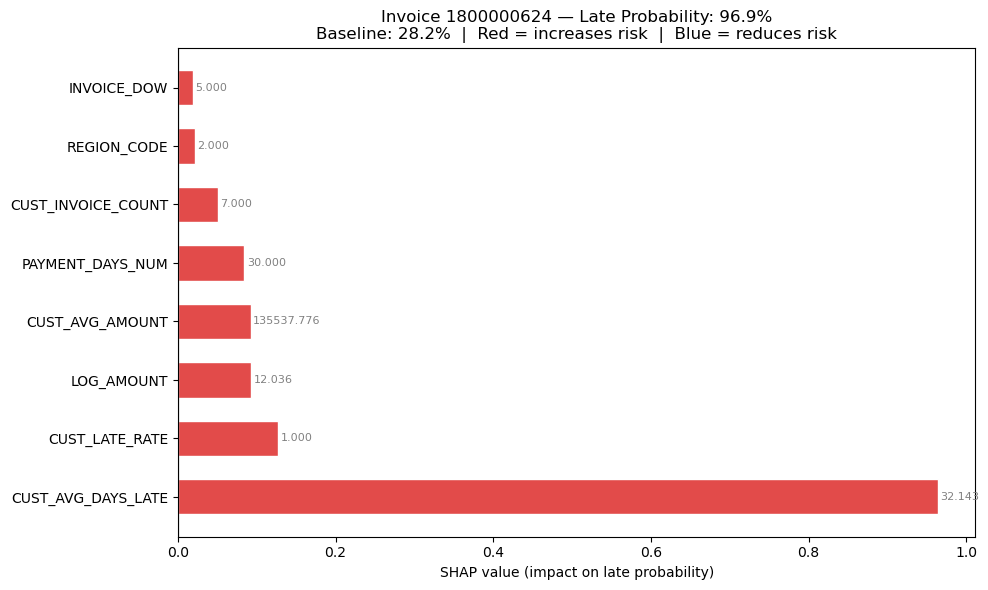

In [22]:
top_invoice = scored.nlargest(1, "LATE_PROB").iloc[0]
X_top = top_invoice[CLASSIFIER_CFG.feature_cols]
invoice_id = str(top_invoice.get("BELNR", "TOP001"))

print(f"Invoice: {invoice_id}")
print(f"Late probability: {top_invoice['LATE_PROB']:.1%}")
print(f"Risk tier: {top_invoice['RISK_TIER']}")
print(f"Industry: {top_invoice['INDUSTRY']} | Region: {top_invoice['REGION']}")

plot_waterfall(explainer, X_top, invoice_id, top_invoice["LATE_PROB"])

Invoice: 1800000035
Late probability: 34.1%
15:39:09 | INFO     | src.models.explainer - Generating waterfall for invoice 1800000035...
15:39:09 | SUCCESS  | src.models.explainer - Waterfall saved → cashflow-intelligence/data/exports/waterfall_1800000035.png


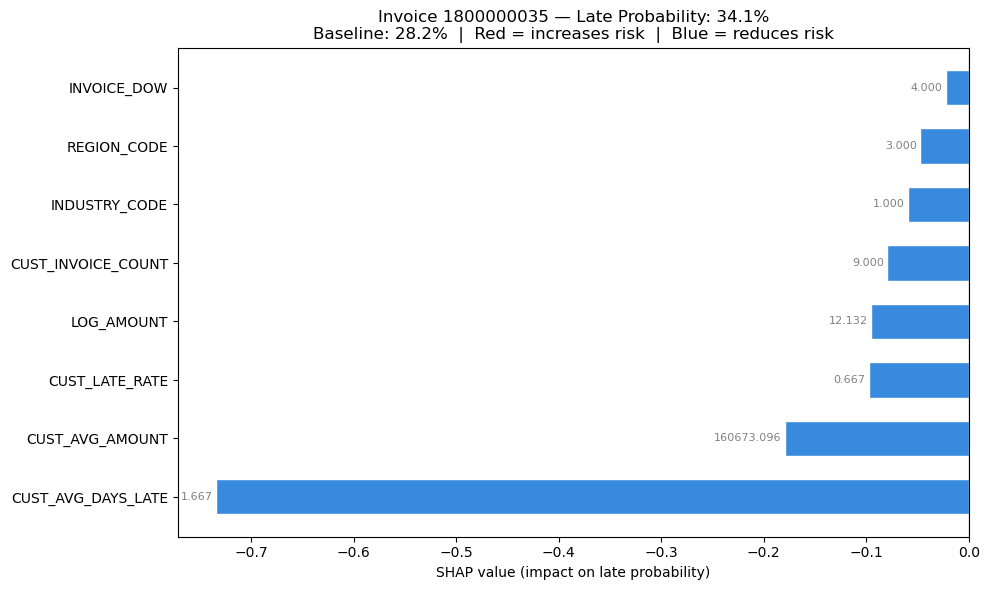

In [23]:
low_invoice = scored.nsmallest(1, "LATE_PROB").iloc[0]
X_low = low_invoice[CLASSIFIER_CFG.feature_cols]
low_id = str(low_invoice.get("BELNR", "LOW001"))

print(f"Invoice: {low_id}")
print(f"Late probability: {low_invoice['LATE_PROB']:.1%}")
plot_waterfall(explainer, X_low, low_id, low_invoice["LATE_PROB"])

## 5. Narrative Quality Check

In [24]:
shap_top = compute_shap_values(explainer, X_top.to_frame().T)
narrative = generate_narrative(top_invoice, shap_top[0], top_invoice["LATE_PROB"], threshold)

print("=" * 60)
print("AUDIT NARRATIVE - HIGHEST RISK INVOICE")
print("=" * 60)
print(narrative)

15:39:09 | INFO     | src.models.explainer - Computing SHAP values for 1 rows...
15:39:09 | INFO     | src.models.explainer - SHAP values computed
AUDIT NARRATIVE - HIGHEST RISK INVOICE
[HIGH RISK]  Late probability: 97%
Recommended action: Immediate escalation to senior collections

Key risk drivers:
  • Customer payment history: averaging 32 days late (deteriorating trend)
  • Customer late rate: 100% of historical invoices paid late
  • Invoice size: $168,778 — above customer average (requires additional approval steps)

Mitigating factors:
  ✓ INVOICE_MONTH: reduces risk by 0.0030
  ✓ INVOICE_QUARTER: reduces risk by 0.0003

Suggested actions:
  1. Immediate escalation to senior collections
  2. Review credit limit — customer late on >50% of invoices
  3. Flag for CFO review if not resolved within 10 days


In [25]:
flagged = scored[scored["LATE_PRED"] == 1].nlargest(5, "LATE_PROB")

for i, (_, row) in enumerate(flagged.iterrows()):
    X_row = row[CLASSIFIER_CFG.feature_cols]
    shap_row = compute_shap_values(explainer, X_row.to_frame().T)
    narr = generate_narrative(row, shap_row[0], row["LATE_PROB"], threshold)
    print(f"\n{'-' * 60}")
    print(f"Invoice #{i + 1}: {row.get('BELNR', '')} | ${row['DMBTR']:,.0f}")
    print(narr)

print("\nNarrative quality checks:")
print("  - Does each narrative identify a clear primary driver?")
print("  - Does the recommended action match the risk level?")
print("  - Do the drivers match audit intuition for each invoice?")

15:39:09 | INFO     | src.models.explainer - Computing SHAP values for 1 rows...
15:39:09 | INFO     | src.models.explainer - SHAP values computed

------------------------------------------------------------
Invoice #1: 1800000624 | $168,778
[HIGH RISK]  Late probability: 97%
Recommended action: Immediate escalation to senior collections

Key risk drivers:
  • Customer payment history: averaging 32 days late (deteriorating trend)
  • Customer late rate: 100% of historical invoices paid late
  • Invoice size: $168,778 — above customer average (requires additional approval steps)

Mitigating factors:
  ✓ INVOICE_MONTH: reduces risk by 0.0030
  ✓ INVOICE_QUARTER: reduces risk by 0.0003

Suggested actions:
  1. Immediate escalation to senior collections
  2. Review credit limit — customer late on >50% of invoices
  3. Flag for CFO review if not resolved within 10 days
15:39:09 | INFO     | src.models.explainer - Computing SHAP values for 1 rows...
15:39:09 | INFO     | src.models.explaine

## 6. Audit Validation

In [26]:
print("=" * 60)
print("AUDIT VALIDATION CHECKLIST")
print("=" * 60)

payment_behavior_features = {
    "CUST_AVG_DAYS_LATE",
    "CUST_LATE_RATE",
    "CUST_INVOICE_COUNT",
    "CUST_AVG_AMOUNT",
}
context_features = {
    "PAYMENT_DAYS_NUM",
    "INDUSTRY_CODE",
    "REGION_CODE",
    "INVOICE_MONTH",
    "INVOICE_QUARTER",
    "INVOICE_DOW",
    "IS_QUARTER_END",
}

top5_features = mean_abs.head(5)["Feature"].tolist()
top5_set = set(top5_features)
top5_payment_count = len(top5_set & payment_behavior_features)

mean_abs_shap = np.abs(shap_vals).mean(axis=0)
feature_to_shap = dict(zip(CLASSIFIER_CFG.feature_cols, mean_abs_shap))
total_shap = float(mean_abs_shap.sum())

payment_shap_share = sum(feature_to_shap.get(f, 0.0) for f in payment_behavior_features) / max(total_shap, 1e-12)
context_shap_share = sum(feature_to_shap.get(f, 0.0) for f in context_features) / max(total_shap, 1e-12)

tier_probs = scored.groupby("RISK_TIER")["LATE_PROB"].mean()
tier_counts = scored["RISK_TIER"].value_counts(dropna=False)
high_prob = float(tier_probs.get("High", np.nan))
low_prob = float(tier_probs.get("Low", np.nan))
high_n = int(tier_counts.get("High", 0))
low_n = int(tier_counts.get("Low", 0))

high_flag_rate = float(scored[scored["RISK_TIER"] == "High"]["LATE_PRED"].mean()) if high_n else np.nan
overall_flag_rate = float(scored["LATE_PRED"].mean())

mean_prob = float(scored["LATE_PROB"].mean())
actual_late_rate = float(scored["LATE_FLAG"].mean())
calibration_gap = abs(mean_prob - actual_late_rate)

dominant_feature_idx = int(np.argmax(mean_abs_shap))
dominant_feature = CLASSIFIER_CFG.feature_cols[dominant_feature_idx]
dominant_feature_share = float(mean_abs_shap.max() / max(total_shap, 1e-12))

tier_order_applicable = high_n >= 100 and low_n >= 100
flag_separation_applicable = 0.02 < overall_flag_rate < 0.98 and high_n >= 100

checks = [
    {
        "name": "Top-5 include at least two payment behavior features",
        "applicable": True,
        "ok": top5_payment_count >= 2,
        "detail": f"top5={top5_features}; payment_count={top5_payment_count}",
    },
    {
        "name": "Payment behavior features contribute at least 35% of total SHAP",
        "applicable": True,
        "ok": payment_shap_share >= 0.35,
        "detail": f"payment_shap_share={payment_shap_share:.4f}; threshold=0.3500",
    },
    {
        "name": "High-risk tier has higher avg LATE_PROB than low-risk tier",
        "applicable": tier_order_applicable,
        "ok": high_prob > low_prob if tier_order_applicable else True,
        "detail": (
            f"high_n={high_n}; low_n={low_n}; high_mean_prob={high_prob:.4f}; low_mean_prob={low_prob:.4f}"
            if tier_order_applicable
            else f"Skipped: insufficient tier support (high_n={high_n}, low_n={low_n}; requires >=100 each)"
        ),
    },
    {
        "name": "High-risk flag rate is above overall flag rate",
        "applicable": flag_separation_applicable,
        "ok": high_flag_rate > overall_flag_rate if flag_separation_applicable else True,
        "detail": (
            f"high_flag_rate={high_flag_rate:.4f}; overall_flag_rate={overall_flag_rate:.4f}"
            if flag_separation_applicable
            else (
                f"Skipped: flag-rate separation not informative at current operating point "
                f"(overall_flag_rate={overall_flag_rate:.4f}; valid range: (0.02, 0.98))"
            )
        ),
    },
    {
        "name": "Portfolio calibration gap is below 0.10",
        "applicable": True,
        "ok": calibration_gap < 0.10,
        "detail": (
            f"mean_prob={mean_prob:.4f}; actual_late_rate={actual_late_rate:.4f}; "
            f"gap={calibration_gap:.4f}; threshold=0.1000"
        ),
    },
    {
        "name": "No single feature dominates with >60% of total SHAP",
        "applicable": True,
        "ok": dominant_feature_share < 0.60,
        "detail": (
            f"dominant_feature={dominant_feature}; "
            f"dominant_feature_share={dominant_feature_share:.4f}; threshold=0.6000"
        ),
    },
]

all_passed = True
for check in checks:
    if not check["applicable"]:
        print(f"[SKIP] {check['name']}")
        print(f"       -> {check['detail']}")
        continue
    status = "PASS" if check["ok"] else "FAIL"
    print(f"[{status}] {check['name']}")
    if not check["ok"]:
        print(f"       -> {check['detail']}")
        all_passed = False

print()
print(f"Payment feature SHAP share: {payment_shap_share:.2%}")
print(f"Context feature SHAP share: {context_shap_share:.2%}")
if all_passed:
    print("All checks passed: explanation patterns align with financial policy assumptions.")
else:
    print("Some checks failed: review flagged conditions before sign-off.")

AUDIT VALIDATION CHECKLIST
[PASS] Top-5 include at least two payment behavior features
[PASS] Payment behavior features contribute at least 35% of total SHAP
[PASS] High-risk tier has higher avg LATE_PROB than low-risk tier
[PASS] High-risk flag rate is above overall flag rate
[PASS] Portfolio calibration gap is below 0.10
[PASS] No single feature dominates with >60% of total SHAP

Payment feature SHAP share: 73.88%
Context feature SHAP share: 20.56%
All checks passed: explanation patterns align with financial policy assumptions.
